<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [12]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [11]:
## Write your code here
print("Column Names:")
print(df.columns.tolist())

# Display shape of the dataset
print(f"\nThe dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

# Display data types and non-null counts
print("\nData Types and Non-Null Counts:")
print(df.info())

Column Names:
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith', 'OfficeStackAsyncAdmired', 'OfficeStackSyncHaveWorkedWith', 'OfficeStackSyncWantToWorkWith', '

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [14]:
## Write your code here
import pandas as pd

print("🔍 Missing Values Per Column:")
print(df.isnull().sum())

# Optional: View percentage of missing values
print("\n📊 Percentage of Missing Values:")
missing_percentage = df.isnull().mean() * 100
print(missing_percentage)

# Step 2: Drop columns with too many missing values (e.g., > 50%)
threshold = 50
columns_to_keep = ['JobSat']
columns_to_drop = [
    col for col in missing_percentage[missing_percentage > threshold].index 
    if col not in columns_to_keep
]
df.drop(columns=columns_to_drop, inplace=True)
print(f"\n🗑️ Dropped columns with more than {threshold}% missing values: {list(columns_to_drop)}")

# Step 3: Impute or remove remaining missing values
# - Fill numeric columns with median
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# - Fill categorical columns with mode
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Final check
print("\n✅ Missing Values After Imputation:")
print(df.isnull().sum().sum(), "missing values remaining.")

🔍 Missing Values Per Column:
ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

📊 Percentage of Missing Values:
ResponseId              0.000000
MainBranch              0.000000
Age                     0.000000
Employment              0.000000
RemoteWork             16.246160
                         ...    
JobSatPoints_11        55.002522
SurveyLength           14.143375
SurveyEase             14.057796
ConvertedCompYearly    64.186928
JobSat                 55.490013
Length: 114, dtype: float64

🗑️ Dropped columns with more than 50% missing values: ['PlatformAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechAdmired', 'AIToolInterested in Using', 'AIToolN

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [15]:
## Write your code here
# Distribution des types d'emploi
print("📌 Distribution de 'Employment' :")
print(df['Employment'].value_counts(dropna=False))
print("\n")

# Distribution de la satisfaction au travail
print("📌 Distribution de 'JobSat' (Satisfaction au travail) :")
print(df['JobSat'].value_counts(dropna=False))
print("\n")

# Distribution de l'expérience professionnelle en années
print("📌 Distribution de 'YearsCodePro' (Expérience professionnelle en codage) :")
print(df['YearsCodePro'].value_counts(dropna=False).sort_index())

📌 Distribution de 'Employment' :
Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but lo

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


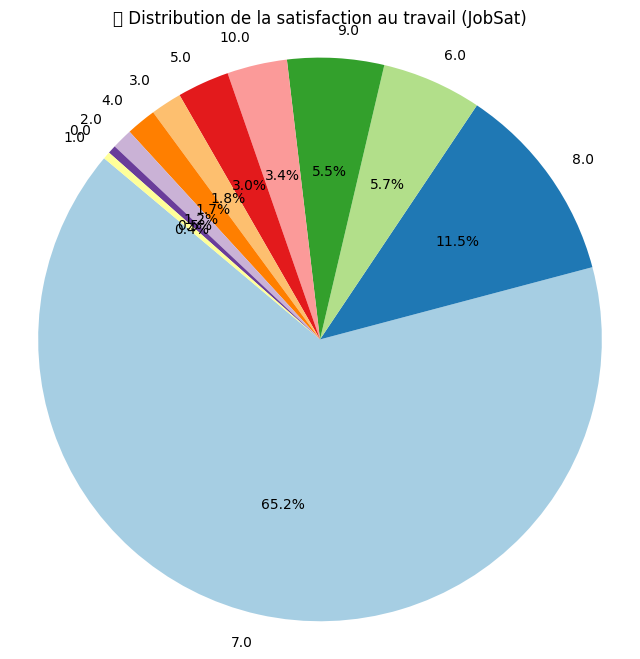

In [16]:
## Write your code here
job_sat_counts = df['JobSat'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(job_sat_counts, labels=job_sat_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("📊 Distribution de la satisfaction au travail (JobSat)")
plt.axis('equal')
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


/tmp/ipykernel_2283/4230954156.py:32: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


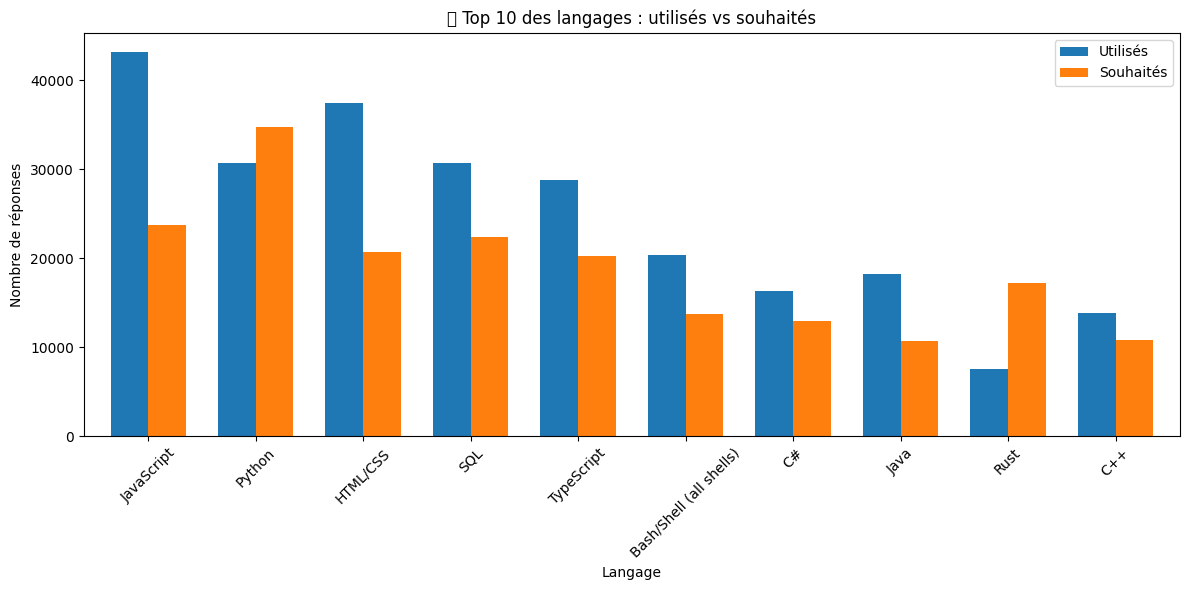

In [17]:
## Write your code here
# Séparer les langages (chaînes de langages séparées par ';') dans chaque colonne
have_worked = df['LanguageHaveWorkedWith'].dropna().str.split(';')
want_to_work = df['LanguageWantToWorkWith'].dropna().str.split(';')

# Aplatir les listes et compter les fréquences
from collections import Counter

lang_worked_counts = Counter([lang.strip() for sublist in have_worked for lang in sublist])
lang_want_counts = Counter([lang.strip() for sublist in want_to_work for lang in sublist])

# Convertir en DataFrame pour fusion
worked_df = pd.DataFrame.from_dict(lang_worked_counts, orient='index', columns=['HaveWorkedWith'])
want_df = pd.DataFrame.from_dict(lang_want_counts, orient='index', columns=['WantToWorkWith'])

# Fusionner les deux
lang_df = worked_df.join(want_df, how='outer').fillna(0)

# Trier par popularité combinée
lang_df['Total'] = lang_df['HaveWorkedWith'] + lang_df['WantToWorkWith']
lang_df = lang_df.sort_values(by='Total', ascending=False).head(10)  # Top 10 langages

# Tracer le bar chart groupé
lang_df[['HaveWorkedWith', 'WantToWorkWith']].plot(
    kind='bar', figsize=(12, 6), width=0.7
)
plt.title("💻 Top 10 des langages : utilisés vs souhaités")
plt.xlabel("Langage")
plt.ylabel("Nombre de réponses")
plt.xticks(rotation=45)
plt.legend(["Utilisés", "Souhaités"], loc='upper right')
plt.tight_layout()
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


/tmp/ipykernel_2283/3865183260.py:18: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


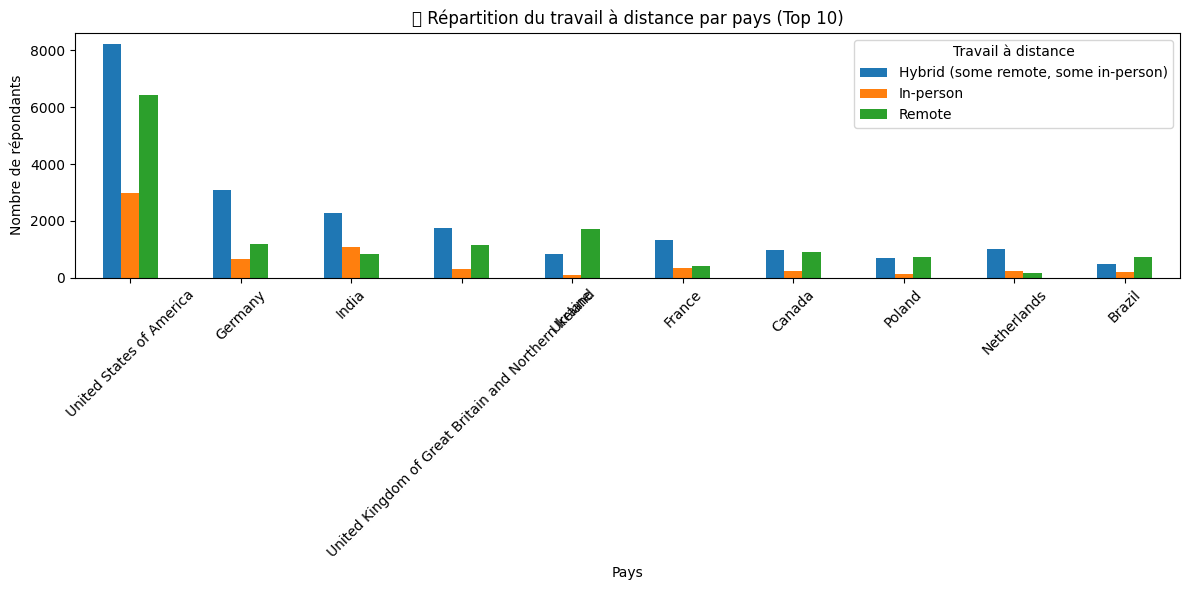

In [18]:
## Write your code here
df_clean = df[['RemoteWork', 'Country']].dropna()

# Compter les occurrences de RemoteWork par Country
remote_counts = df_clean.groupby(['Country', 'RemoteWork']).size().unstack(fill_value=0)

# Trier les pays par total de répondants pour les plus représentés
top_countries = remote_counts.sum(axis=1).sort_values(ascending=False).head(10).index
remote_counts_top = remote_counts.loc[top_countries]

# Tracer un bar chart groupé
remote_counts_top.plot(kind='bar', figsize=(12, 6))
plt.title("🌍 Répartition du travail à distance par pays (Top 10)")
plt.xlabel("Pays")
plt.ylabel("Nombre de répondants")
plt.xticks(rotation=45)
plt.legend(title="Travail à distance")
plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [21]:
## Write your code here
df_corr = df[['JobSat', 'YearsCodePro']].dropna()

# Vérifier les types de données (assurer que ce sont des numériques)
print("Types de données après nettoyage :")
print(df_corr.dtypes)

# Calculer la corrélation de Spearman
corr, p_value = spearmanr(df_corr['JobSat'], df_corr['YearsCodePro'])

print(f"\nSpearman correlation coefficient: {corr:.3f}")
print(f"P-value: {p_value:.4f}")

Types de données après nettoyage :
JobSat          float64
YearsCodePro     object
dtype: object

Spearman correlation coefficient: -0.006
P-value: 0.1019


In [22]:
from scipy.stats import spearmanr

# Convertir 'YearsCodePro' en numérique (en forçant les erreurs en NaN si nécessaire)
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Garder uniquement les lignes avec des valeurs valides pour les deux colonnes
df_corr = df[['JobSat', 'YearsCodePro']].dropna()

# Vérifier les types de données après conversion
print("\nTypes de données après conversion :")
print(df_corr.dtypes)

# Calculer la corrélation de Spearman
corr, p_value = spearmanr(df_corr['JobSat'], df_corr['YearsCodePro'])

print(f"\nSpearman correlation coefficient: {corr:.3f}")
print(f"P-value: {p_value:.4f}")



Types de données après conversion :
JobSat          float64
YearsCodePro    float64
dtype: object

Spearman correlation coefficient: 0.106
P-value: 0.0000


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


Cross-tabulation (Employment vs. EdLevel):
EdLevel                                             Associate degree (A.A., A.S., etc.)  \
Employment                                                                                
Employed, full-time                                                                1059   
Employed, full-time;Employed, part-time                                               9   
Employed, full-time;Independent contractor, fre...                                  104   
Employed, full-time;Independent contractor, fre...                                   11   
Employed, full-time;Independent contractor, fre...                                    0   
...                                                                                 ...   
Student, full-time;Student, part-time;Employed,...                                    0   
Student, full-time;Student, part-time;Retired                                         0   
Student, part-time                             

/tmp/ipykernel_2283/802456701.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


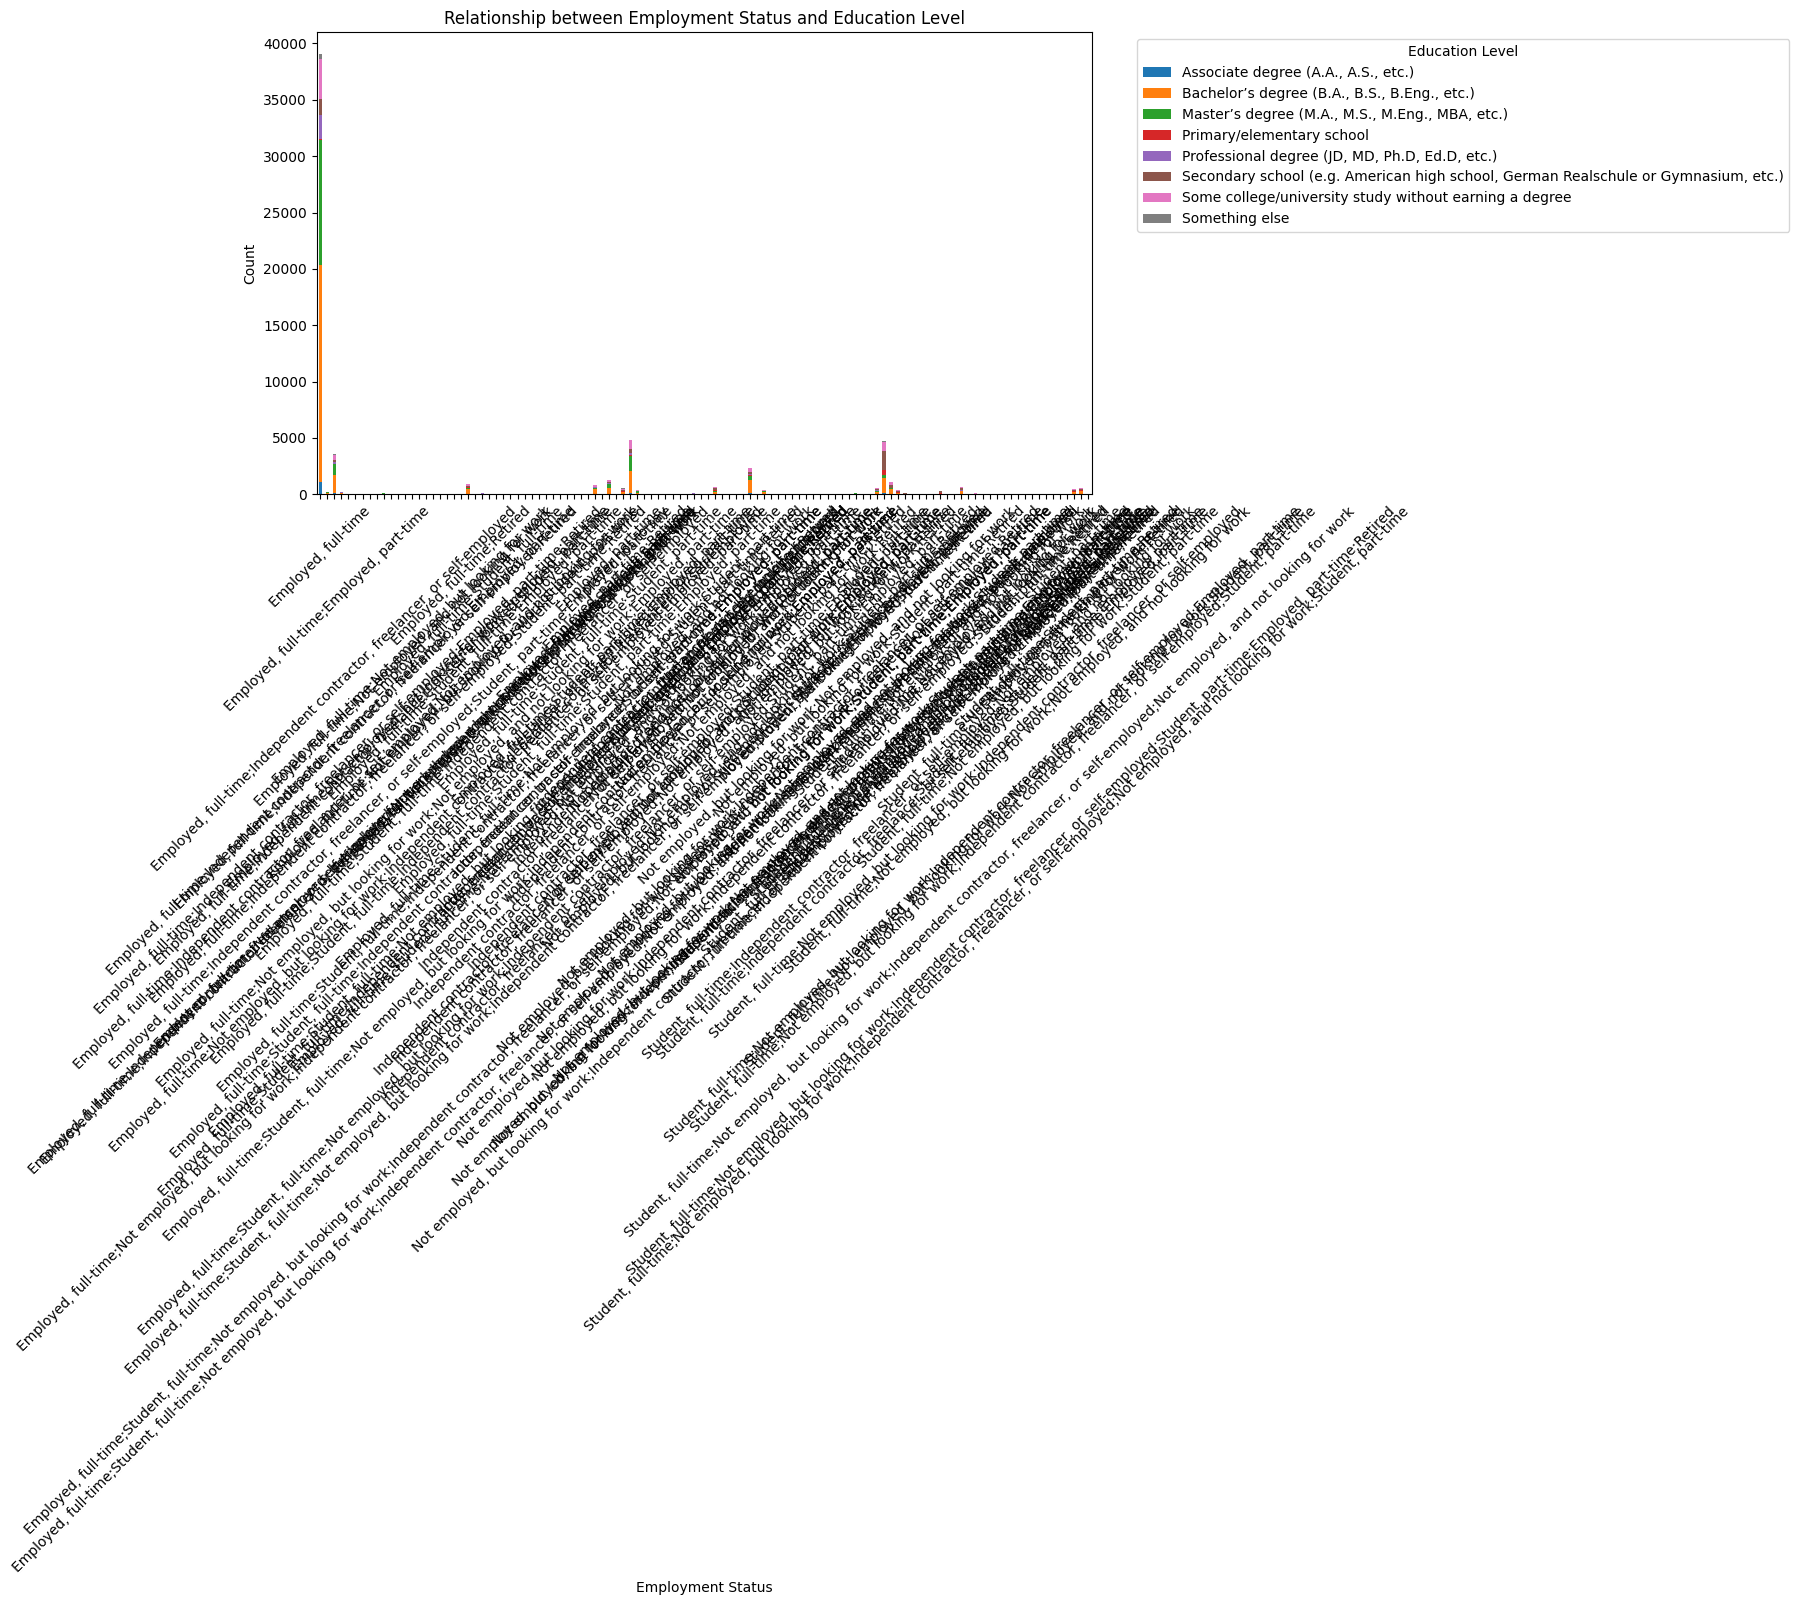

In [23]:
## Write your code here
# Créer la table de contingence entre Employment et EdLevel
cross_tab = pd.crosstab(df['Employment'], df['EdLevel'])

# Afficher la table de contingence
print("Cross-tabulation (Employment vs. EdLevel):")
print(cross_tab)

# Visualiser la table de contingence avec un graphique en barres empilées
cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6))

# Ajouter des titres et labels
plt.title('Relationship between Employment Status and Education Level')
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Education Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# Afficher le graphique
plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [24]:
## Write your code here
df.to_csv('eda_cleaned_dataset.csv', index=False)

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
